<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/Day3/ML_K_Mean_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Load the dataset
data=pd.read_csv('/content/environmental factors.csv')
#display first few rows
print (data.head())
print(data.shape)

   temperature   humidity  ...  solar_irradiance  pollution_level
0    22.490802  52.418449  ...        369.020837        84.723658
1    34.014286  49.974726  ...        185.335998        49.451704
2    29.639879  40.569235  ...        213.723302        19.546561
3    26.973170  66.436000  ...        262.604015        73.664179
4    18.120373  58.597450  ...        283.288001        41.867814

[5 rows x 6 columns]
(10000, 6)


   temperature  humidity  ...  solar_irradiance  pollution_level
0    -0.415900 -0.452465  ...         -0.684316         1.193409
1     1.587377 -0.593258  ...         -1.389866        -0.029923
2     0.826917 -1.135149  ...         -1.280827        -1.067119
3     0.363328  0.355146  ...         -1.093072         0.809835
4    -1.175669 -0.096466  ...         -1.013623        -0.292954

[5 rows x 6 columns]


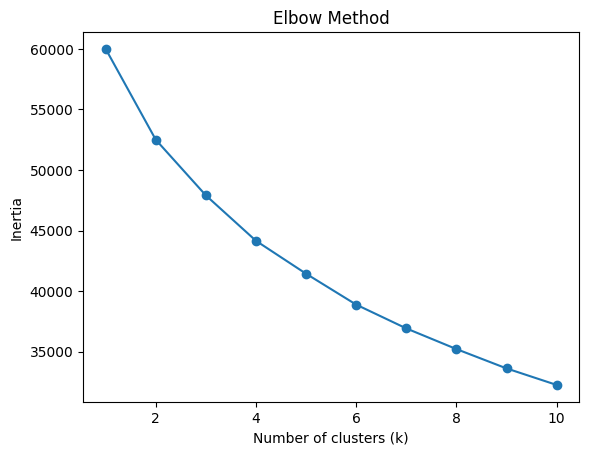

In [ ]:
# Normalize the features using StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
# Display scaled data
print(pd.DataFrame(data_scaled, columns=data.columns).head())

# Use the Elbow method to find the optimal number of clusters
inertia = []
k_range = range(1, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)


# Plot the inertia values to find the "elbow"
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
data["cluster"]=kmeans.fit_predict(data_scaled)

In [ ]:
print(data.head)

<bound method NDFrame.head of       temperature   humidity  ...  pollution_level  cluster
0       22.490802  52.418449  ...        84.723658        4
1       34.014286  49.974726  ...        49.451704        0
2       29.639879  40.569235  ...        19.546561        4
3       26.973170  66.436000  ...        73.664179        0
4       18.120373  58.597450  ...        41.867814        4
...           ...        ...  ...              ...      ...
9995    32.153120  82.622318  ...        96.614073        3
9996    32.950177  32.808837  ...        37.323996        4
9997    33.934158  48.221908  ...        30.467486        0
9998    22.949760  56.599200  ...        40.736253        2
9999    19.342808  40.335889  ...        52.283339        2

[10000 rows x 7 columns]>


In [ ]:
#new data clustering (Giving data)
new_data=[[25,60,20,500,300,50]]
new_cluster=kmeans.predict(new_data)[0]
print("\n New Household belongs to cluster :",new_cluster)


 New Household belongs to cluster : 3


In [ ]:
#Calculate Silhouette Score
sil_score = silhouette_score(data_scaled, data['cluster'])
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.11929995200284398


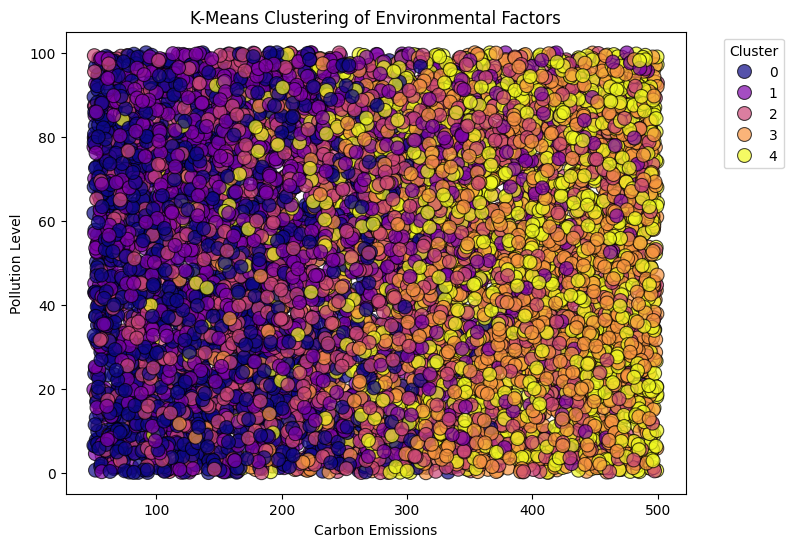

In [ ]:
from pandas.plotting import parallel_coordinates
# Assuming `data` already contains the cluster labels (from the KMeans model)
# We'll use two features to plot: 'carbon_emissions' and 'pollution_level'
plt.figure(figsize=(8, 6))
# Create a scatter plot with the cluster labels
sns.scatterplot(x='carbon_emissions', y='pollution_level', hue='cluster',
                data=data,  s=100, palette='plasma', alpha=0.7, edgecolor='k')
# Title and labels
plt.title('K-Means Clustering of Environmental Factors')
plt.xlabel('Carbon Emissions')
plt.ylabel('Pollution Level')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
# Display the plot
plt.show()